- R²
- Loss curves (both models on one plot)
- Predicted vs actual scatter plots
- Written conclusion

In [2]:
#Imports to run models
import sklearn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

from preprocessing import df_basic_cleaning_and_split, array_standardise_data, df_feature_constructions
from model1_baseline import train_NN, forward

In [3]:
include_added_features = False
if include_added_features:  
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3)
    X_train, X_test = df_feature_constructions(X_train, X_test)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
else:
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3, include_additional_features=False)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
    
print(X_train[0])

[ 0.13350629  0.50935748  0.18106017 -0.27384968 -0.18411678 -0.01082519
 -0.80568191  0.78093406]


In [4]:
#MODEL 1 - ANALYSIS - from model1_baseline.ipynb
def predict(X, W1, b1, w2, b2):
    y_hat, _ = forward(X, W1, b1, w2, b2)
    return y_hat

In [5]:
W1_t, b1_t, w2_t, b2_t, losses_nn = train_NN(X_train, y_train, lr=0.001, iters=10000, seed=2)

R²: 0.6106249747251404


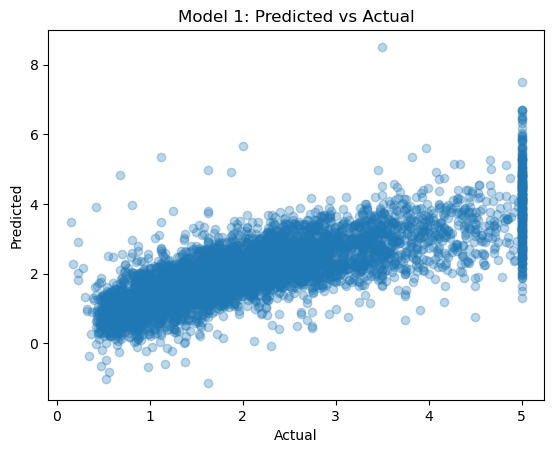

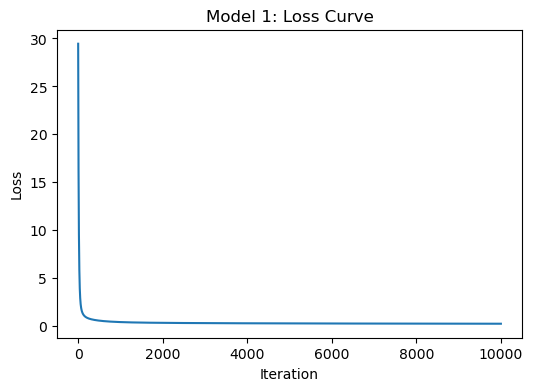

In [6]:
predicted = predict(X_test, W1_t, b1_t, w2_t, b2_t)
r2 = r2_score(y_test, predicted)
print("R²:", r2)

plt.scatter(y_test, predicted, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model 1: Predicted vs Actual")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(losses_nn)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Model 1: Loss Curve")
plt.show()

In [7]:
#MODEL 2 - Analysis - from model2_sklearn.ipynb

In [8]:
y_train = y_train.flatten()
y_test = y_test.flatten()

clf = MLPRegressor(activation='relu', solver='sgd', alpha=1e-5, learning_rate='constant',
                   learning_rate_init=0.001,
                    hidden_layer_sizes=(64), random_state=1, max_iter=10_000)

clf.fit(X_train, y_train)


MLPRegressor(alpha=1e-05, hidden_layer_sizes=64, max_iter=10000, random_state=1,
             solver='sgd')

R²: 0.7614651236837975


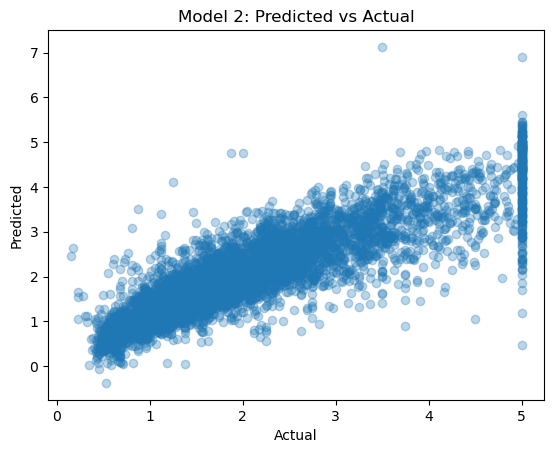

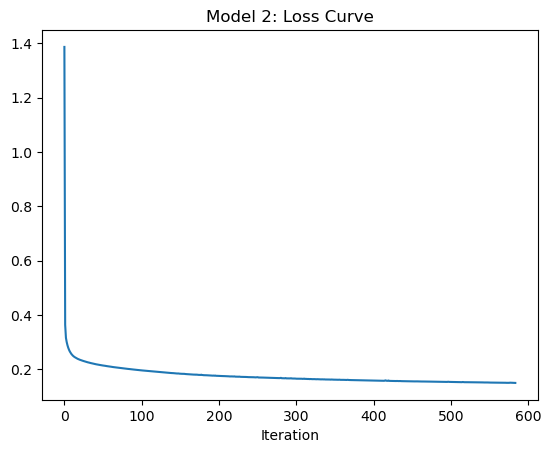

In [9]:
predicted_2 = clf.predict(X_test)
r2 = r2_score(y_test, predicted_2)
print("R²:", r2)

plt.scatter(y_test, predicted_2, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model 2: Predicted vs Actual")
plt.show()

plt.plot(clf.loss_curve_)
plt.xlabel("Iteration")
plt.title("Model 2: Loss Curve")
plt.show()



In [10]:
# Last loss
print("Model 1 final loss:", losses_nn[-1])
print("Model 2 final loss:", clf.loss_curve_[-1])

Model 1 final loss: 0.25450749193843414
Model 2 final loss: 0.15058228678671812


*Model 2 is clearly the better model, supported by the above analysis. More depth in final report.